In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model


In [3]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [5]:
input_dim = 784
latent_dim = 2

In [7]:
inputs = layers.Input(shape=(input_dim,))
h = layers.Dense(64, activation='relu')(inputs)

In [8]:
z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

In [9]:
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [10]:
z = layers.Lambda(sampling)([z_mean, z_log_var])

In [11]:
decoder_h = layers.Dense(64, activation='relu')
decoder_mean = layers.Dense(input_dim, activation='sigmoid')
h_decoded = decoder_h(z)
outputs = decoder_mean(h_decoded)

In [12]:
vae = Model(inputs, outputs)

In [14]:
import keras

In [16]:
def vae_loss(inputs, outputs, z_mean, z_log_var):
    reconstruction_loss = keras.ops.mean(keras.ops.sum(keras.ops.binary_crossentropy(inputs, outputs), axis=-1))
    kl_loss = -0.5 * keras.ops.mean(keras.ops.sum(1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var), axis=-1))
    return reconstruction_loss + kl_loss

In [17]:
class VAE_Loss_Layer(layers.Layer):
    def call(self, inputs):
        loss = vae_loss(inputs[0], inputs[1], inputs[2], inputs[3])
        self.add_loss(loss)
        return inputs[1]

In [18]:
outputs = VAE_Loss_Layer()([inputs, outputs, z_mean, z_log_var])

In [19]:
vae = Model(inputs, outputs)

In [20]:
vae.compile(optimizer='adam')

In [21]:
vae.fit(x_train, x_train, epochs=20, batch_size=128, validation_data=(x_test, x_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 223.0819 - val_loss: 187.6527
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 182.9732 - val_loss: 177.7545
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 176.0794 - val_loss: 173.1120
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 172.3872 - val_loss: 170.6273
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 170.3591 - val_loss: 169.0680
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 168.8227 - val_loss: 167.8206
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 167.5965 - val_loss: 166.5542
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 166.4609 - val_loss: 165.6924
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 165.3777 - val_loss: 164.8393
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 164.4761 - val_loss: 163.8766
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 163.6852 - val_loss: 163.1992
Epoch 12

In [22]:
import matplotlib.pyplot as plt

In [23]:
n = 10
digit_size = 28
figure = np.zeros((digit_size * 1, digit_size * n))

In [30]:
for i in range(n):
    z_sample = np.random.normal(size=(1, latent_dim))
    x_decoded = decoder_h(z_sample)
    x_decoded = decoder_mean(x_decoded)
    digit = x_decoded.numpy().reshape(digit_size, digit_size)
    figure[0:digit_size, i * digit_size: (i + 1) * digit_size] = digit



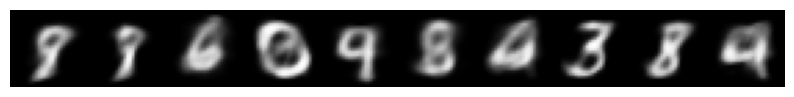

In [31]:
plt.figure(figsize=(10, 2))
plt.imshow(figure, cmap='Greys_r')
plt.axis('off')
plt.show()

In [32]:
encoder = Model(inputs, z_mean)
x_test_encoded = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step


In [34]:
encoder = Model(inputs, [z_mean, z_log_var, z])

In [35]:
decoder_input = layers.Input(shape=(latent_dim,))
x = decoder_h(decoder_input)
decoder_output = decoder_mean(x)
decoder = Model(decoder_input, decoder_output)

In [36]:
x_decoded = decoder.predict(z_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [37]:
x_decoded

array([[1.71699668e-08, 3.52701583e-08, 4.08707237e-08, 1.84676114e-08,
        1.27979511e-08, 2.82176043e-08, 1.23638788e-08, 2.45259848e-08,
        1.17537615e-08, 1.30360629e-08, 1.40303005e-08, 2.71433880e-08,
        1.72073851e-06, 1.03352722e-05, 4.52019640e-06, 4.70310582e-08,
        1.90642364e-08, 1.53531499e-08, 1.80736652e-08, 1.85121571e-08,
        7.19879978e-09, 1.17691057e-08, 1.56971343e-08, 3.18123803e-08,
        2.76069869e-08, 1.02653139e-08, 1.61005538e-08, 2.09628634e-08,
        1.25270985e-08, 6.07710593e-09, 1.38120182e-08, 1.83460713e-08,
        8.66025616e-08, 6.47209504e-07, 3.40584324e-06, 6.78934612e-06,
        1.38880841e-05, 9.20709954e-06, 5.90208356e-06, 2.98853820e-06,
        2.51181918e-05, 2.01993807e-05, 4.92309082e-05, 6.52152230e-05,
        1.56157665e-04, 5.65905648e-04, 4.41968878e-04, 6.54934265e-04,
        7.27928826e-04, 3.02649423e-04, 1.22119716e-04, 6.42705709e-06,
        3.43186137e-08, 1.43540930e-08, 1.80311091e-08, 1.467544

In [38]:
reconstructed = vae.predict(x_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


In [39]:
reconstructed

array([[6.1761050e-08, 3.4938225e-07, 6.4444896e-07, ..., 3.2985326e-08,
        7.7680397e-08, 1.4086767e-07],
       [8.6117808e-08, 5.5649590e-08, 4.2263352e-08, ..., 8.9646257e-08,
        6.2294276e-08, 7.2770355e-08],
       [4.1256434e-10, 5.7752675e-10, 7.1231332e-09, ..., 2.7281316e-10,
        7.7297091e-10, 4.7322379e-10],
       ...,
       [2.0569599e-08, 5.9575552e-08, 6.8516108e-08, ..., 1.0851456e-08,
        3.7491787e-08, 5.5576713e-08],
       [6.9740310e-07, 6.4976859e-07, 6.0006562e-07, ..., 5.6297245e-07,
        7.6348391e-07, 8.8655764e-07],
       [6.2023770e-07, 1.8477327e-06, 2.5511897e-06, ..., 4.1137670e-07,
        9.1473487e-07, 1.0705414e-06]], dtype=float32)

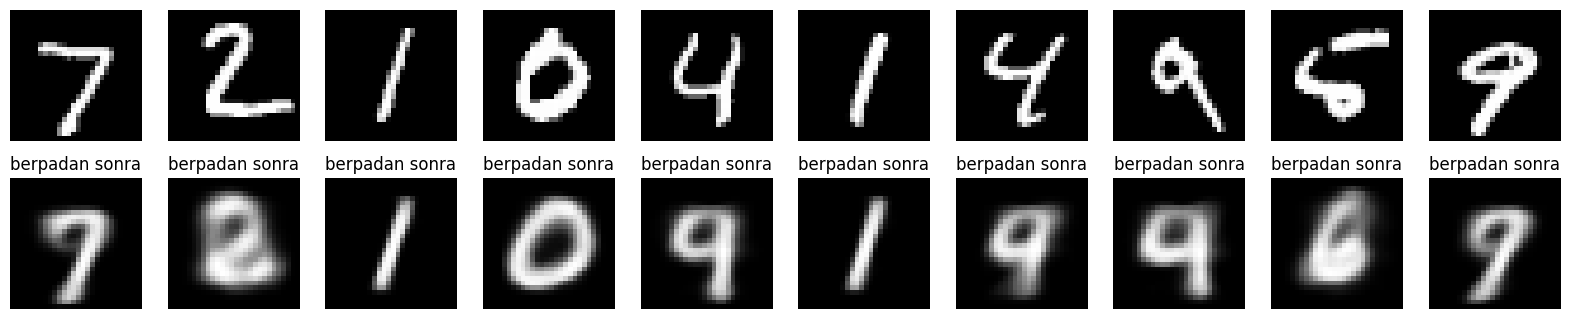

In [41]:
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='Greys_r')
    plt.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='Greys_r')
    plt.title("berpadan sonra")
    plt.axis('off')
plt.show()